# BatchManager exploration

This notebook mirrors the optimizer walkthrough in `test_optim.ipynb`, but uses two observed branches with different observation sizes. It compares a strict `BatchManager` configuration with equal numbers of child batches and a resampling configuration with unequal child batch counts.

In [1]:
import jax
import jax.numpy as jnp
import optax
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.experimental.optim as opt
import liesel.model as lsl
from liesel.experimental.optim.types import Position

The two branches below have different observation sizes. The `PositionSplit` keeps both full arrays in the training position; each child `Batches` object owns one observed variable.

In [2]:
data_key = jax.random.key(42)
x_key, y_key = jax.random.split(data_key)

xval = 1.5 + 0.7 * jax.random.normal(x_key, (1_200,))
yval = -0.5 + 1.3 * jax.random.normal(y_key, (800,))

data = opt.PositionSplit(
    train=Position({"x": xval, "y": yval}),
    validate=Position({}),
    test=Position({}),
    n_train=max(xval.size, yval.size),
    n_validate=0,
    n_test=0,
)

The strict configuration uses different observation sizes but the same number of full child batches. The resampling configuration intentionally uses unequal child batch counts and lets the shorter child sequence sample rows again within a joint epoch.

In [3]:
def make_strict_batches():
    return opt.BatchManager(
        [
            opt.Batches(["x"], n=xval.size, batch_size=120, shuffle=True),
            opt.Batches(["y"], n=yval.size, batch_size=80, shuffle=True),
        ],
        mode="strict",
    )


def make_resample_batches():
    return opt.BatchManager(
        [
            opt.Batches(["x"], n=xval.size, batch_size=150, shuffle=True),
            opt.Batches(["y"], n=yval.size, batch_size=80, shuffle=True),
        ],
        mode="resample",
        epoch_size="max",
    )


strict_batches = make_strict_batches()
resample_batches = make_resample_batches()

In [4]:
def summarize_batches(manager):
    return {
        "mode": manager.mode,
        "n": manager.n,
        "batch_size": manager.batch_size,
        "batch_shares": manager.batch_shares,
        "n_full_batches": manager.n_full_batches,
        "is_full_data": manager.is_full_data,
    }


summarize_batches(strict_batches), summarize_batches(resample_batches)

({'mode': 'strict',
  'n': (1200, 800),
  'batch_size': (120, 80),
  'batch_shares': (10.0, 10.0),
  'n_full_batches': 10,
  'is_full_data': False},
 {'mode': 'resample',
  'n': (1200, 800),
  'batch_size': (150, 80),
  'batch_shares': (8.0, 10.0),
  'n_full_batches': 10,
  'is_full_data': False})

`start_epoch()` prepares child-specific permutations and the joint sequence of child batch rows. Creating a fresh manager before starting an epoch keeps the notebook cells independent when they are re-run out of order.

In [5]:
strict_epoch = make_strict_batches().start_epoch(jax.random.key(1))
resample_epoch = make_resample_batches().start_epoch(jax.random.key(1))

strict_epoch.batch_numbers[:5], resample_epoch.batch_numbers[:5]

(Array([[0, 0],
        [1, 1],
        [2, 2],
        [3, 3],
        [4, 4]], dtype=int32),
 Array([[7, 0],
        [1, 3],
        [3, 8],
        [0, 2],
        [5, 4]], dtype=int32))

In [6]:
def batch_shapes(manager, batch_index=0):
    batch = manager.get_batched_position(data.train, batch_index)
    return {name: value.shape for name, value in batch.items()}


batch_shapes(strict_epoch), batch_shapes(resample_epoch)

({'x': (120,), 'y': (80,)}, {'x': (150,), 'y': (80,)})

Scalar likelihood scaling is still available when all child batch shares match. With unequal shares, use `scaled_log_lik()` so each branch receives its own scaling factor.

In [7]:
strict_batches.batch_share

10.0

In [8]:
try:
    resample_batches.batch_share
except ValueError as error:
    print(error)

BatchManager.batch_share is only available when all contained Batches objects have the same n / batch_size. Use per-branch scaling via BatchManager.scaled_log_lik() instead.


The model has two independent observed branches. The initial model is built from one joint mini-batch because the observed variables receive their batched values during optimization.

In [9]:
def build_model(initial_batch):
    m_x = lsl.Var.new_param(0.0, name="m_x")
    s_x = lsl.Var.new_param(1.0, name="s_x")
    s_x.transform(tfb.Exp())

    m_y = lsl.Var.new_param(0.0, name="m_y")
    s_y = lsl.Var.new_param(1.0, name="s_y")
    s_y.transform(tfb.Exp())

    x = lsl.Var.new_obs(
        initial_batch["x"],
        distribution=lsl.Dist(tfd.Normal, loc=m_x, scale=s_x),
        name="x",
    )
    y = lsl.Var.new_obs(
        initial_batch["y"],
        distribution=lsl.Dist(tfd.Normal, loc=m_y, scale=s_y),
        name="y",
    )

    return lsl.Model([x, y])

In [10]:
manager = make_resample_batches().start_epoch(jax.random.key(2))
initial_batch = manager.get_batched_position(data.train, 0)
p = build_model(initial_batch)
state = p.update_state(initial_batch, p.state)

manual_scaled_log_lik = (
    manager.batches[0].batch_share * state["x_log_prob"].value.sum()
    + manager.batches[1].batch_share * state["y_log_prob"].value.sum()
)

(
    manager.scaled_log_lik(p, state),
    manual_scaled_log_lik,
    jnp.allclose(
        manager.scaled_log_lik(p, state),
        manual_scaled_log_lik,
    ),
)

(Array(-4323.078, dtype=float32),
 Array(-4323.078, dtype=float32),
 Array(True, dtype=bool))

The helper below builds a fresh model, loss, optimizer, and engine for each batch configuration.

In [11]:
def build_engine(batch_manager, seed=42, learning_rate=1e-2):
    batch_manager = batch_manager.start_epoch(jax.random.key(seed))
    initial_batch = batch_manager.get_batched_position(data.train, 0)
    p = build_model(initial_batch)

    loss = opt.NegLogProbLoss(
        model=p,
        split=data,
        validation_strategy="log_lik",
    )
    optimizer = opt.Optimizer(
        list(p.parameters),
        optimizer=optax.adam(learning_rate=learning_rate),
    )

    engine = opt.OptimEngine(
        loss=loss,
        batches=batch_manager,
        split=data,
        optimizers=[optimizer],
        stopper=opt.Stopper(epochs=500, patience=50, atol=0.0, rtol=1e-4),
        seed=seed,
        initial_state=p.state,
        restore_best_position=True,
        prune_history=True,
        show_progress=True,
        save_position_history=False,
        progress_n_updates=100,
    )
    return p, engine

Run the strict configuration first.

In [12]:
p_strict, engine_strict = build_engine(make_strict_batches(), seed=11)
result_strict = engine_strict.fit()

Training loss: 2605.972, Validation loss: 2605.972:  15%|█▌        | 75/500 [00:00<00:05, 79.26it/s] 


Then run the resampling configuration.

In [13]:
p_resample, engine_resample = build_engine(make_resample_batches(), seed=11)
result_resample = engine_resample.fit()

Training loss: 2598.753, Validation loss: 2598.753:  24%|██▎       | 118/500 [00:00<00:02, 189.77it/s]


In [14]:
def summarize_result(result):
    position = result.best_position
    return {
        "m_x": float(position["m_x"]),
        "s_x": float(jnp.exp(position["s_x_transformed"])),
        "m_y": float(position["m_y"]),
        "s_y": float(jnp.exp(position["s_y_transformed"])),
        "best_epoch": result.best_epoch,
        "final_epoch": result.final_epoch,
    }


{
    "truth": {"m_x": 1.5, "s_x": 0.7, "m_y": -0.5, "s_y": 1.3},
    "strict": summarize_result(result_strict),
    "resample": summarize_result(result_resample),
}

{'truth': {'m_x': 1.5, 's_x': 0.7, 'm_y': -0.5, 's_y': 1.3},
 'strict': {'m_x': 1.5300757884979248,
  's_x': 0.6873095631599426,
  'm_y': -0.5758274793624878,
  's_y': 1.310958981513977,
  'best_epoch': 28,
  'final_epoch': 74},
 'resample': {'m_x': 1.5277271270751953,
  's_x': 0.6876116394996643,
  'm_y': -0.5737999081611633,
  's_y': 1.3226871490478516,
  'best_epoch': 67,
  'final_epoch': 117}}

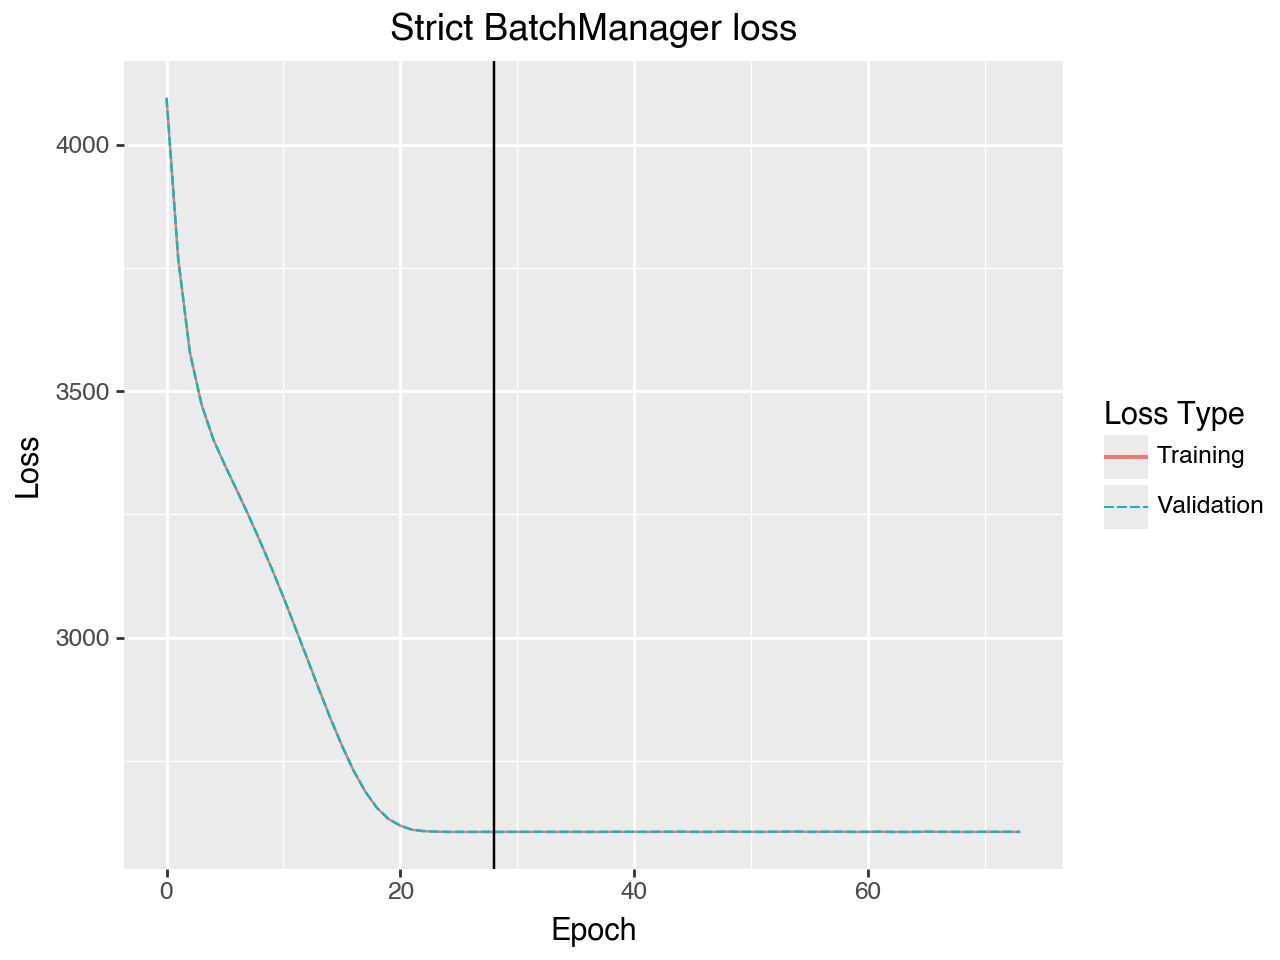

In [15]:
result_strict.plot_loss(title="Strict BatchManager loss")

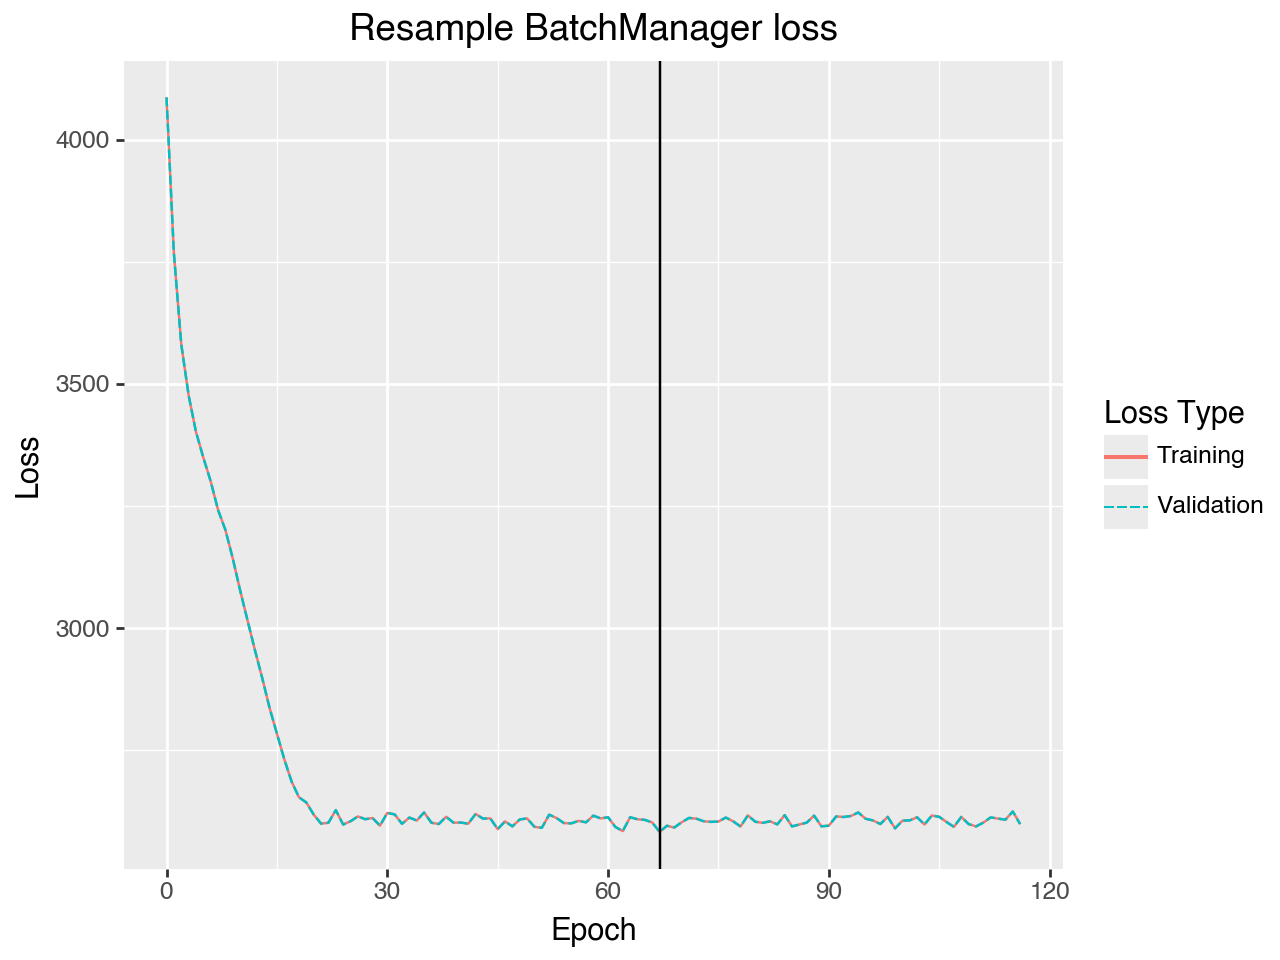

In [16]:
result_resample.plot_loss(title="Resample BatchManager loss")

Useful knobs to change while exploring: child `batch_size`, `mode`, `epoch_size`, `shuffle`, `Stopper` settings, and the optimizer learning rate.